In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

conn = duckdb.connect("../data/home_credit.db")
print("Connected to database ✓")

Matplotlib is building the font cache; this may take a moment.


Connected to database ✓


     income_band  applicant_count  defaults  default_rate_pct
0  1. Under 100k            63698    5225.0              8.20
1   2. 100k-200k           155898   13326.0              8.55
2   3. 200k-400k            79852    5806.0              7.27
3   4. 400k-700k             7325     433.0              5.91
4       5. 700k+              738      35.0              4.74


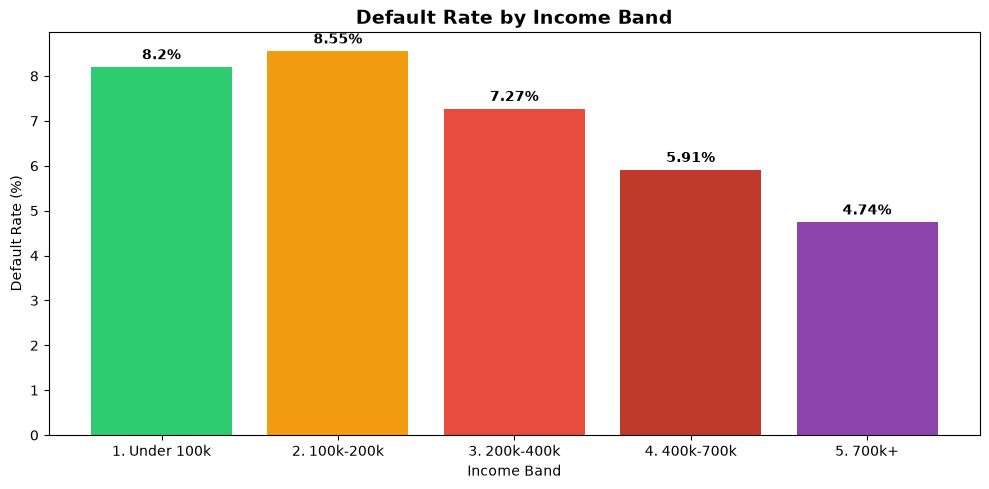

Chart saved!


In [2]:
# Load analysis result from SQL mart
income_data = conn.execute("SELECT * FROM analysis_default_by_income").fetchdf()
print(income_data)

# Chart
plt.figure(figsize=(10, 5))
bars = plt.bar(income_data['income_band'], income_data['default_rate_pct'], 
               color=['#2ecc71','#f39c12','#e74c3c','#c0392b','#8e44ad'])
plt.title('Default Rate by Income Band', fontsize=14, fontweight='bold')
plt.xlabel('Income Band')
plt.ylabel('Default Rate (%)')
for bar, val in zip(bars, income_data['default_rate_pct']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
             f'{val}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/charts/default_by_income.png', dpi=150)
plt.show()
print("Chart saved!")

           payment_behaviour  applicants  default_rate_pct
0              1. Never Late      136644              6.80
1       2. Rarely Late (<5%)       38987              6.92
2  3. Sometimes Late (5-20%)       76255              9.34
3     4. Often Late (20-50%)       36609             11.64
4      5. Mostly Late (>50%)        3148             15.82


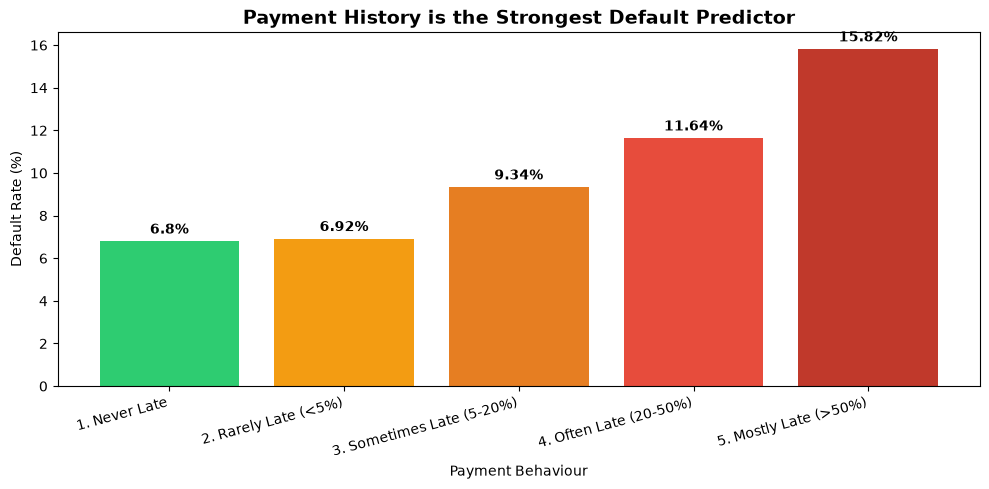

Chart saved!


In [3]:
# Load payment behaviour analysis
payment_data = conn.execute("SELECT * FROM analysis_payment_behaviour").fetchdf()
print(payment_data)

# Chart
plt.figure(figsize=(10, 5))
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
bars = plt.bar(payment_data['payment_behaviour'], 
               payment_data['default_rate_pct'], color=colors)
plt.title('Payment History is the Strongest Default Predictor', 
          fontsize=14, fontweight='bold')
plt.xlabel('Payment Behaviour')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, payment_data['default_rate_pct']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
             f'{val}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/charts/payment_vs_default.png', dpi=150)
plt.show()
print("Chart saved!")

   risk_quintile  applicants  default_rate_pct  avg_credit_income_ratio
0              1       61503              7.33                     1.27
1              2       61502              8.57                     2.28
2              3       61502              8.92                     3.28
3              4       61502              8.28                     4.75
4              5       61502              7.25                     8.21


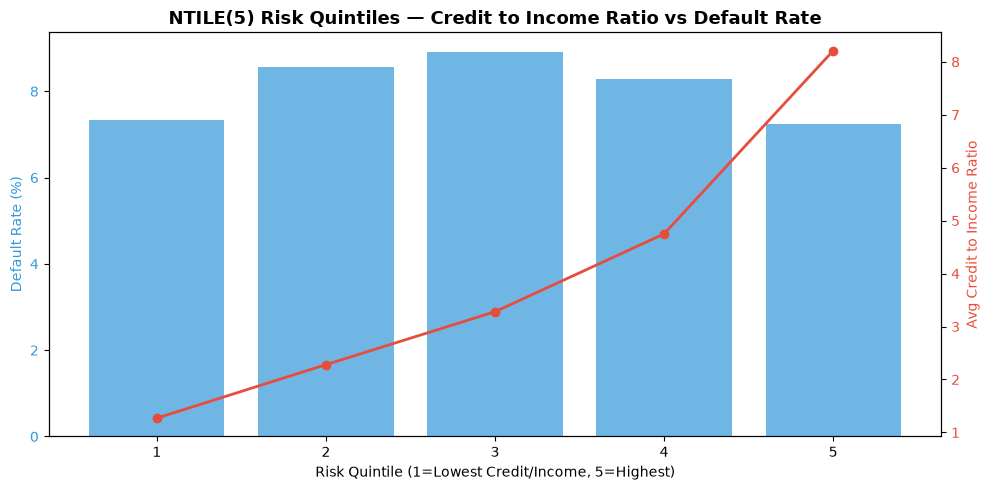

Chart saved!


In [4]:
# Load NTILE analysis
ntile_data = conn.execute("SELECT * FROM analysis_ntile_risk").fetchdf()
print(ntile_data)

# Chart
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = '#3498db'
ax1.bar(ntile_data['risk_quintile'], ntile_data['default_rate_pct'], 
        color=color1, alpha=0.7, label='Default Rate %')
ax1.set_xlabel('Risk Quintile (1=Lowest Credit/Income, 5=Highest)')
ax1.set_ylabel('Default Rate (%)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.plot(ntile_data['risk_quintile'], ntile_data['avg_credit_income_ratio'], 
         color=color2, marker='o', linewidth=2, label='Avg Credit/Income Ratio')
ax2.set_ylabel('Avg Credit to Income Ratio', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('NTILE(5) Risk Quintiles — Credit to Income Ratio vs Default Rate', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/charts/ntile_risk.png', dpi=150)
plt.show()
print("Chart saved!")

             NAME_EDUCATION_TYPE  applicants  default_rate_pct  risk_rank
0                Lower secondary        3816             10.93          1
1  Secondary / secondary special      218391              8.94          2
2              Incomplete higher       10277              8.48          3
3               Higher education       74863              5.36          4


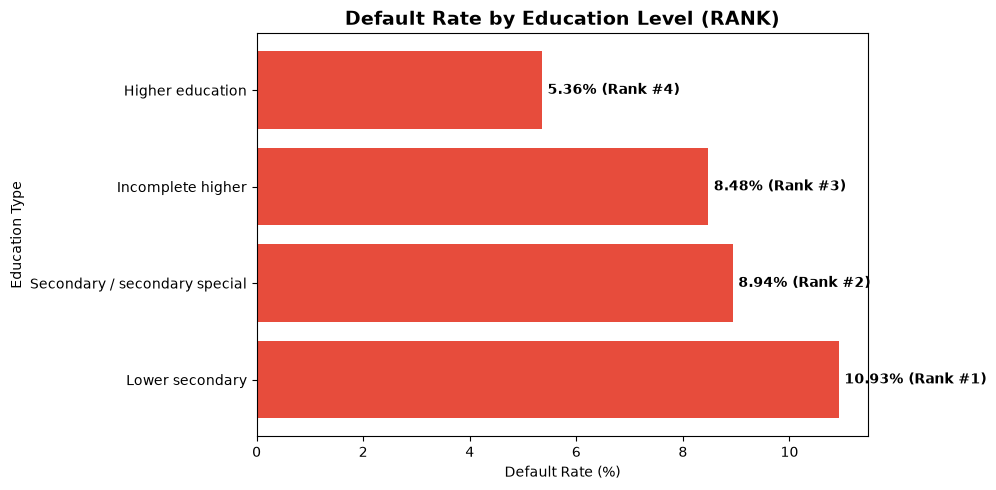

Chart saved!


In [5]:
# Load education rank analysis
edu_data = conn.execute("SELECT * FROM analysis_education_rank").fetchdf()
print(edu_data)

# Chart
plt.figure(figsize=(10, 5))
bars = plt.barh(edu_data['NAME_EDUCATION_TYPE'], edu_data['default_rate_pct'],
                color='#e74c3c')
plt.title('Default Rate by Education Level (RANK)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Default Rate (%)')
plt.ylabel('Education Type')
for bar, val, rank in zip(bars, edu_data['default_rate_pct'], edu_data['risk_rank']):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2.,
             f'{val}% (Rank #{rank})', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/charts/education_rank.png', dpi=150)
plt.show()
print("Chart saved!")

In [6]:
# Load the full feature mart
df = conn.execute("SELECT * FROM mart_applicant_features").fetchdf()
print(f"Feature mart shape: {df.shape}")
print(f"Default rate: {df['TARGET'].mean():.2%}")

Feature mart shape: (307511, 41)
Default rate: 8.07%


In [7]:
# Select feature columns
feature_cols = [
    # Application features
    'age_years', 'years_employed', 'CNT_CHILDREN',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'credit_to_income_ratio', 'annuity_to_income_ratio',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    # Bureau features
    'bureau_loan_count', 'bureau_active_loans', 'bureau_total_debt',
    'bureau_overdue_rate', 'bureau_debt_ratio',
    # Installment features
    'inst_late_payment_rate', 'inst_avg_days_late',
    'inst_max_days_late', 'inst_payment_ratio',
    # Previous application features
    'prev_app_count', 'prev_refused_count', 'prev_approval_rate',
    # Credit card features
    'cc_avg_days_past_due', 'cc_avg_utilisation', 'cc_months_overdue'
]

X = df[feature_cols].copy()
y = df['TARGET'].copy()

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

print(f"Features: {X_imputed.shape[1]}")
print(f"Samples: {X_imputed.shape[0]:,}")
print(f"Class balance: {y.value_counts().to_dict()}")


Features: 26
Samples: 307,511
Class balance: {0: 282686, 1: 24825}


In [8]:
# Split 80% train, 20% test
# stratify=y ensures same default rate in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"Train default rate: {y_train.mean():.2%}")
print(f"Test default rate:  {y_test.mean():.2%}")


Train size: 246,008
Test size:  61,503
Train default rate: 8.07%
Test default rate:  8.07%


In [9]:
# Baseline: always predict no default (majority class)
# This is what we need to BEAT with our real model
baseline_predictions = np.zeros(len(y_test))
baseline_auc = roc_auc_score(y_test, baseline_predictions)

print("=" * 45)
print("BASELINE MODEL (always predict 0)")
print("=" * 45)
print(f"AUC Score: {baseline_auc:.4f}")
print("A real model must score higher than 0.50")

BASELINE MODEL (always predict 0)
AUC Score: 0.5000
A real model must score higher than 0.50


In [10]:
print("Training Logistic Regression...")
lr = LogisticRegression(
    class_weight='balanced',  # handles 91%/9% imbalance
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)

print("=" * 45)
print("LOGISTIC REGRESSION")
print("=" * 45)
print(f"AUC Score: {lr_auc:.4f}")
print(f"Beats baseline by: {lr_auc - 0.5:.4f}")

Training Logistic Regression...
LOGISTIC REGRESSION
AUC Score: 0.6010
Beats baseline by: 0.1010


In [11]:
print("Training Random Forest (this may take 3-5 minutes)...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1        # use all CPU cores to speed it up
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)

print("=" * 45)
print("RANDOM FOREST")
print("=" * 45)
print(f"AUC Score: {rf_auc:.4f}")
print(f"Beats baseline by: {rf_auc - 0.5:.4f}")
print(f"Beats Logistic Regression by: {rf_auc - lr_auc:.4f}")

Training Random Forest (this may take 3-5 minutes)...
RANDOM FOREST
AUC Score: 0.7462
Beats baseline by: 0.2462
Beats Logistic Regression by: 0.1451


FINAL MODEL COMPARISON
Model                                 AUC
-------------------------------------------------------
Baseline (always predict 0)        0.5000
Logistic Regression                0.6010
Random Forest                      0.7462

Best model: Random Forest (AUC = 0.7462)


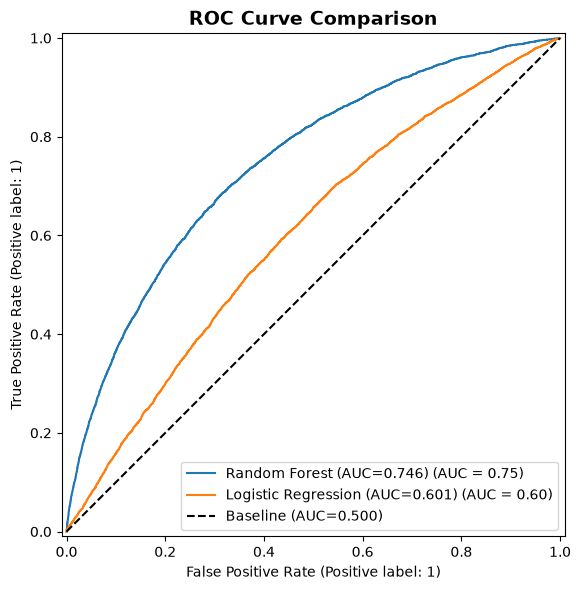

ROC curve saved!


In [12]:
# Model comparison summary
print("=" * 55)
print("FINAL MODEL COMPARISON")
print("=" * 55)
print(f"{'Model':<30} {'AUC':>10}")
print("-" * 55)
print(f"{'Baseline (always predict 0)':<30} {0.5000:>10.4f}")
print(f"{'Logistic Regression':<30} {lr_auc:>10.4f}")
print(f"{'Random Forest':<30} {rf_auc:>10.4f}")
print("=" * 55)
print(f"\nBest model: Random Forest (AUC = {rf_auc:.4f})")

# ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, rf_proba, 
                                  name=f'Random Forest (AUC={rf_auc:.3f})', ax=ax)
RocCurveDisplay.from_predictions(y_test, lr_proba, 
                                  name=f'Logistic Regression (AUC={lr_auc:.3f})', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Baseline (AUC=0.500)')
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../dashboard/charts/roc_curve.png', dpi=150)
plt.show()
print("ROC curve saved!")

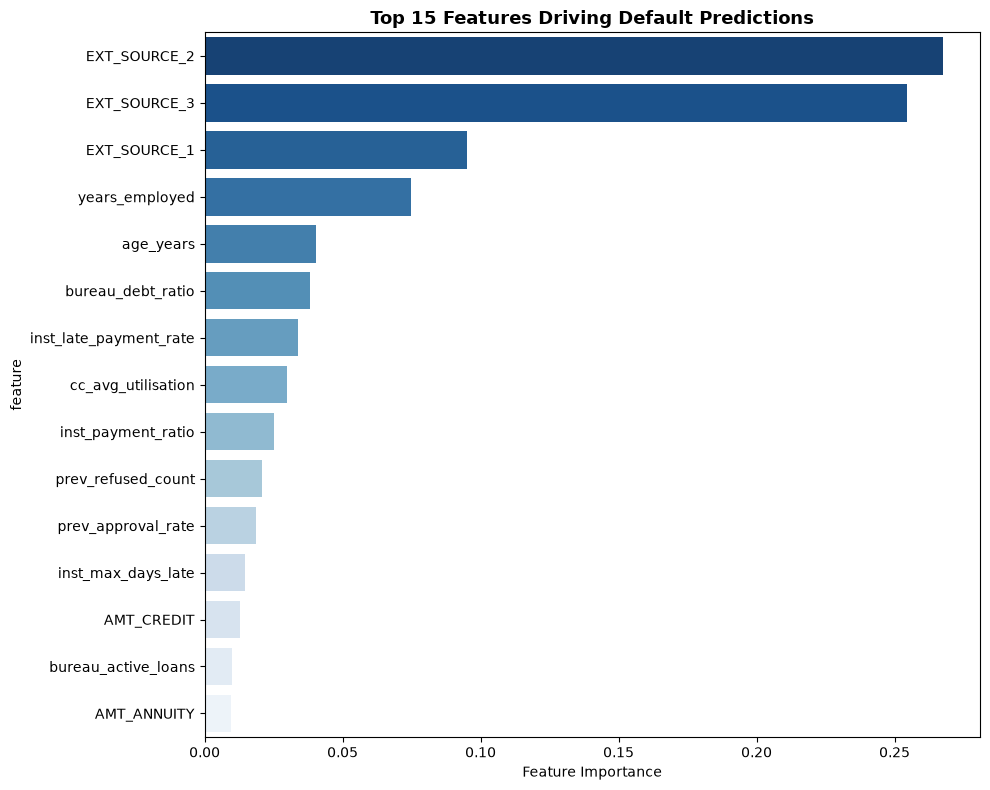


Top 5 default predictors:
       feature  importance
  EXT_SOURCE_2    0.267578
  EXT_SOURCE_3    0.254471
  EXT_SOURCE_1    0.094893
years_employed    0.074952
     age_years    0.040402


In [13]:
# Which features drive the predictions most?
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature', palette='Blues_r')
plt.title('Top 15 Features Driving Default Predictions', 
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('../dashboard/charts/feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 default predictors:")
print(feat_imp.head(5)[['feature', 'importance']].to_string(index=False))

In [14]:
# What is the real business cost of our model's errors?
from sklearn.metrics import confusion_matrix

best_preds = (rf_proba >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, best_preds).ravel()

print("=" * 55)
print("CONFUSION MATRIX & BUSINESS COST ANALYSIS")
print("=" * 55)
print(f"True Positives  (correctly caught defaults):  {tp:,}")
print(f"False Positives (wrongly flagged as risky):   {fp:,}")
print(f"True Negatives  (correctly approved):         {tn:,}")
print(f"False Negatives (missed defaults = BAD DEBT): {fn:,}")
print()
print("Business Cost Interpretation:")
print(f"  False Approvals ({fn:,}): Lent money to people who defaulted")
print(f"  False Declines  ({fp:,}): Rejected good customers (lost revenue)")
print()
avg_loan = 500000
print(f"  Estimated bad debt from {fn:,} missed defaults:")
print(f"  GHS {fn * avg_loan:,.0f}")
print()
print("Conclusion: Minimising False Approvals saves the most money")
print(f"Our model catches {tp:,} true defaulters — protecting the lender")

CONFUSION MATRIX & BUSINESS COST ANALYSIS
True Positives  (correctly caught defaults):  3,357
False Positives (wrongly flagged as risky):   17,347
True Negatives  (correctly approved):         39,191
False Negatives (missed defaults = BAD DEBT): 1,608

Business Cost Interpretation:
  False Approvals (1,608): Lent money to people who defaulted
  False Declines  (17,347): Rejected good customers (lost revenue)

  Estimated bad debt from 1,608 missed defaults:
  GHS 804,000,000

Conclusion: Minimising False Approvals saves the most money
Our model catches 3,357 true defaulters — protecting the lender


In [15]:
conn.close()
print("Analysis complete! Database connection closed.")
print()
print("=" * 55)
print("PROJECT SUMMARY")
print("=" * 55)
print("Dataset:     Home Credit Default Risk (7 tables)")
print("Applicants:  307,511")
print("Features:    26 (SQL-engineered from 5 tables)")
print("Best Model:  Random Forest")
print(f"AUC Score:   {rf_auc:.4f} (vs 0.50 baseline)")
print("Dashboard:   Streamlit (next step)")
print("=" * 55)

Analysis complete! Database connection closed.

PROJECT SUMMARY
Dataset:     Home Credit Default Risk (7 tables)
Applicants:  307,511
Features:    26 (SQL-engineered from 5 tables)
Best Model:  Random Forest
AUC Score:   0.7462 (vs 0.50 baseline)
Dashboard:   Streamlit (next step)
